# Capstone 2: Sales Analysis - South Carolina & Texas

**Analyst:** Cris Ramirez  
**Region:** South  
**Territories:** South Carolina & Texas

## <u>Project Overview</u>
EmporiUm's marketing team wants a closer look at how the South Carolina and Texas territories are performing. This notebook digs into in store sales data to answer questions about store rankings, top customers, monthly revenue trends, and product category performance, then wraps up with a recommendation for where to focus marketing efforts next quarter.

-------------------------

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv('data/StoreSales.csv')
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [3]:
stores = pd.read_csv('data/StoreDetail.csv')
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [4]:
products = pd.read_csv('data/Products.csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [5]:
categories = pd.read_csv('data/ProductCategories.csv')
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [6]:
customers = pd.read_csv('data/customer_list.csv', sep='|')
customers.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


-------------------------

# Core Marketing Analysis

## Q1: Territory Managers and Stores
**Question:** Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

In [7]:
my_stores = stores[stores['State'].isin(['South Carolina', 'Texas'])]
my_stores

,Store Location,State,Store ID,Territory Manager,Region,Region Director
98,Charleston,South Carolina,852,Len Jensen,South,Andy Gisselquist
99,Greenville,South Carolina,853,Len Jensen,South,Andy Gisselquist
100,Arlington,Texas,901,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
101,Austin,Texas,902,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
102,Bacliff,Texas,903,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
103,Baytown,Texas,904,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
104,Beaumont,Texas,905,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
105,Cedar Park,Texas,906,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
106,Dallas,Texas,907,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
107,Denton,Texas,908,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


**answer:**
- **south carolina** (2 stores): charleston (852) and greenville (853), managed by **len jensen**
- **texas** (11 stores): arlington, austin, bacliff, baytown, beaumont, cedar park, dallas, denton, desoto, fort worth, and georgetown (store ids 901–911), managed by **jeff "howdy" richards**
- both territories are in the **south region** under regional director **andy gisselquist**

-------------------------

## Q2: Monthly Revenue Trend
**Question:** What is monthly total revenue for in-store sales in each of the two sales territories, over the full
period covered by the data?

In [8]:
my_store_ids = my_stores['Store ID']
my_sales = sales[sales['Store ID'].isin(my_store_ids)]
my_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28684 entries, 129 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction Date  28684 non-null  object 
 1   Store ID          28684 non-null  int64  
 2   RewardsID         2947 non-null   float64
 3   Prod Num          28684 non-null  object 
 4   Sale Amount       28684 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.3+ MB


In [9]:
my_sales = my_sales.copy()
my_sales['Transaction Date'] = pd.to_datetime(my_sales['Transaction Date'])
my_sales['Year-Month'] = my_sales['Transaction Date'].dt.to_period('M')
my_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Year-Month
129,2022-01-01,853,NaN,105453-T,159.58,2022-01
137,2022-01-01,902,NaN,105454-M,14.00,2022-01
138,2022-01-01,904,NaN,105326-IT,1717.70,2022-01
139,2022-01-01,906,NaN,105347-IT,837.52,2022-01
140,2022-01-01,906,NaN,105348-IT,29.81,2022-01


In [10]:
my_sales = my_sales.merge(my_stores[['Store ID', 'State']], on='Store ID')
my_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Year-Month,State
0,2022-01-01,853,NaN,105453-T,159.58,2022-01,South Carolina
1,2022-01-01,902,NaN,105454-M,14.00,2022-01,Texas
2,2022-01-01,904,NaN,105326-IT,1717.70,2022-01,Texas
3,2022-01-01,906,NaN,105347-IT,837.52,2022-01,Texas
4,2022-01-01,906,NaN,105348-IT,29.81,2022-01,Texas


In [11]:
monthly_revenue = my_sales.groupby(['State', 'Year-Month'])['Sale Amount'].sum().reset_index()
monthly_revenue

,State,Year-Month,Sale Amount
0,South Carolina,2022-01,9640.38
1,South Carolina,2022-02,9763.98
2,South Carolina,2022-03,8366.63
3,South Carolina,2022-04,8929.63
4,South Carolina,2022-05,5396.03
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


In [12]:
monthly_revenue.groupby('State')['Sale Amount'].agg(['min', 'max', 'mean']).round(0)

,min,max,mean
State,,,
South Carolina,5396.0,34375.0,13517.0
Texas,40857.0,168956.0,71205.0


**answer:**

data covers january 2022 to december 2025 (4 years).

- south carolina: $5k–$34k per month, 2 stores
- texas: $41k–$169k per month, 11 stores

texas earns more overall, but it also has 5x more stores. q3 will show which territory does better per store.

-------------------------

## Q3: Store Performance Ranking
**Question:** How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

In [13]:
store_revenue = my_sales.groupby(['State', 'Store ID'])['Sale Amount'].sum().reset_index()
store_revenue = store_revenue.sort_values('Sale Amount', ascending=False)
store_revenue

,State,Store ID,Sale Amount
6,Texas,905,637818.90
11,Texas,910,351772.59
1,South Carolina,853,337002.00
10,Texas,909,330720.12
7,Texas,906,312628.27
0,South Carolina,852,311810.56
5,Texas,904,298163.16
9,Texas,908,298111.45
2,Texas,901,292987.49
3,Texas,902,291145.00


In [14]:
store_revenue = store_revenue.merge(my_stores[['Store ID', 'Store Location']], on='Store ID')
store_revenue

,State,Store ID,Sale Amount,Store Location
0,Texas,905,637818.90,Beaumont
1,Texas,910,351772.59,Fort Worth
2,South Carolina,853,337002.00,Greenville
3,Texas,909,330720.12,Desoto
4,Texas,906,312628.27,Cedar Park
5,South Carolina,852,311810.56,Charleston
6,Texas,904,298163.16,Baytown
7,Texas,908,298111.45,Denton
8,Texas,901,292987.49,Arlington
9,Texas,902,291145.00,Austin


**answer:**

- **top store:** beaumont, tx (#905) at $637k
- **south carolina is doing well for its size:** charleston (#852) and greenville (#853) both beat 7 of the 11 texas stores
- **bottom of the list:** dallas, tx (#907) at $54k. below the others

-------------------------

## Q4: Top Customers
**Question:** Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

In [15]:
rewards_sales = my_sales[my_sales['RewardsID'].notna()]
rewards_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2947 entries, 7 to 28680
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction Date  2947 non-null   datetime64[ns]
 1   Store ID          2947 non-null   int64         
 2   RewardsID         2947 non-null   float64       
 3   Prod Num          2947 non-null   object        
 4   Sale Amount       2947 non-null   float64       
 5   Year-Month        2947 non-null   period[M]     
 6   State             2947 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2), period[M](1)
memory usage: 184.2+ KB


In [16]:
rewards_sales = rewards_sales.merge(
    customers[['cust_id', 'name']],
    how='left',
    left_on='RewardsID',
    right_on='cust_id'
)
rewards_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Year-Month,State,cust_id,name
0,2022-01-01,908,328.0,105337-IT,1301.88,2022-01,Texas,328,Monica Reyes
1,2022-01-02,901,29.0,105487-S,9.95,2022-01,Texas,29,Samwell T.
2,2022-01-02,904,444.0,105531-A,57.70,2022-01,Texas,444,Charlotte York
3,2022-01-03,853,454.0,105424-T,192.26,2022-01,South Carolina,454,Saul Goodman
4,2022-01-04,903,77.0,105518-M,20.36,2022-01,Texas,77,Nicholas Brody


In [17]:
top_customers = rewards_sales.groupby(['State', 'cust_id', 'name'])['Sale Amount'].sum().reset_index()
top_customers = top_customers.sort_values('Sale Amount', ascending=False)
top_customers

,State,cust_id,name,Sale Amount
641,Texas,344,Nate Jacobs,5240.86
770,Texas,474,Christopher Moltisanti,3479.46
400,Texas,102,Jodie L.,3464.91
466,Texas,168,Darius,3400.35
568,Texas,271,Maeby F.,3127.53
...,...,...,...,...
243,South Carolina,426,Carla T.,2.88
139,South Carolina,237,Alex Vause,2.88
195,South Carolina,351,Cal Jacobs,2.40
297,South Carolina,517,Perry the Platypus,2.40


In [18]:
top_sc = top_customers[top_customers['State'] == 'South Carolina'].head(5)
top_tx = top_customers[top_customers['State'] == 'Texas'].head(5)

print("Top 5 Customers — South Carolina")
print("-------------------------------")
print(top_sc)
print()
print("Top 5 Customers — Texas")
print("-------------------------------")
print(top_tx)

Top 5 Customers — South Carolina
-------------------------------
              State  cust_id       name  Sale Amount
186  South Carolina      340   Jin Kwon      1786.05
229  South Carolina      404  Roman Roy      1778.84
122  South Carolina      213       Jazz      1763.70
42   South Carolina       74  Ben Chang      1566.60
157  South Carolina      280   Cal Abar      1396.50

Top 5 Customers — Texas
-------------------------------
     State  cust_id                    name  Sale Amount
641  Texas      344             Nate Jacobs      5240.86
770  Texas      474  Christopher Moltisanti      3479.46
400  Texas      102                Jodie L.      3464.91
466  Texas      168                  Darius      3400.35
568  Texas      271                Maeby F.      3127.53


**answer:**

**south carolina top 5:**
1. jin kwon - $1,786
2. roman roy - $1,778
3. jazz - $1,763
4. ben chang - $1,566
5. cal abar - $1,396

**texas top 5:**
1. nate jacobs - $5,240
2. christopher moltisanti - $3,479
3. jodie l. - $3,464
4. darius - $3,400
5. maeby f. - $3,127

texas has more rewards members and they spend more. even tx's #5 customer beats sc's #1 by $1,300. nate jacobs stands out, worth a special offer to keep him coming back.

only 10% of transactions come from rewards members. growing the rewards program, especially in south carolina, is a big opportunity.

-------------------------

## Q5: Category Trends
**Question:** What is the number of transactions per month by product category in each assigned territory? 
What is total sales revenue per month by category? 
What might this tell you about the most popular products, and where could there be opportunity for growth?

In [19]:
sales_cat = my_sales.merge(products, on='Prod Num', how='left')
sales_cat = sales_cat.merge(categories, on=['CategoryID', 'SubcategoryID'], how='left')

print("transactions with no category:", sales_cat['Category'].isna().sum())
sales_cat.head()

transactions with no category: 276


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Year-Month,State,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,853,NaN,105453-T,159.58,2022-01,South Carolina,Organizational Behavior,100,100-bus,Textbooks,Business & Economics
1,2022-01-01,902,NaN,105454-M,14.00,2022-01,Texas,LTCA Year Up USB Flash Drive (64GB),130,130-tec,Apparel and Merchandise,Technology Accessories
2,2022-01-01,904,NaN,105326-IT,1717.70,2022-01,Texas,"Apple MacBook Air (M2, 13-inch)",120,120-lap,Technology & Accessories,Laptops
3,2022-01-01,906,NaN,105347-IT,837.52,2022-01,Texas,Google Pixel Tablet,120,120-tab,Technology & Accessories,Tablets
4,2022-01-01,906,NaN,105348-IT,29.81,2022-01,Texas,HP 65W Slim Charger,120,120-cha,Technology & Accessories,Chargers and Power Adapters


In [20]:
category_monthly = sales_cat.groupby(['State', 'Year-Month', 'Category']).agg(
    Transactions=('Sale Amount', 'count'),
    Revenue=('Sale Amount', 'sum')
).reset_index()
category_monthly.head(20)

,State,Year-Month,Category,Transactions,Revenue
0,South Carolina,2022-01,Apparel and Merchandise,12,257.20
1,South Carolina,2022-01,Art Supplies,8,369.83
2,South Carolina,2022-01,Books (General),4,96.16
3,South Carolina,2022-01,Stationery and Supplies,7,61.09
4,South Carolina,2022-01,Technology & Accessories,13,7503.43
5,South Carolina,2022-01,Textbooks,9,1352.67
6,South Carolina,2022-02,Apparel and Merchandise,13,624.50
7,South Carolina,2022-02,Art Supplies,10,225.93
8,South Carolina,2022-02,Books (General),6,186.72
9,South Carolina,2022-02,Stationery and Supplies,11,102.74


In [21]:
category_totals = sales_cat.groupby(['State', 'Category']).agg(
    Transactions=('Sale Amount', 'count'),
    Revenue=('Sale Amount', 'sum')
).reset_index()
category_totals = category_totals.sort_values(['State', 'Revenue'], ascending=[True, False])
category_totals

,State,Category,Transactions,Revenue
4,South Carolina,Technology & Accessories,977,472118.34
5,South Carolina,Textbooks,588,103238.99
0,South Carolina,Apparel and Merchandise,907,30414.72
1,South Carolina,Art Supplies,890,28003.49
2,South Carolina,Books (General),345,9809.53
3,South Carolina,Stationery and Supplies,906,9135.99
10,Texas,Technology & Accessories,5219,2445117.66
11,Texas,Textbooks,3423,596616.41
6,Texas,Apparel and Merchandise,4406,142403.22
7,Texas,Art Supplies,4427,139084.75


**answer:**

both states rank categories the same way. tech leads, books and stationery come last.

| rank | category | sc revenue | tx revenue |
|---|---|---|---|
| 1 | technology & accessories | $472k | $2.4m |
| 2 | textbooks | $103k | $597k |
| 3 | apparel & merchandise | $30k | $142k |
| 4 | art supplies | $28k | $139k |
| 5 | books (general) | $10k | $58k |
| 6 | stationery & supplies | $9k | $54k |

lots of transactions doesn't mean lots of money. stationery sells the most, but tech earns 45x more per sale. the money is in tech and textbooks.

**opportunities:** push textbooks during back to school, keep tech strong, scale back on books

-------------------------

## Q6: Recommendation
**Question:** What is your recommendation for where to focus marketing attention in the next quarter?

**recommendation:**

based on the analysis, next quarter's marketing should focus on three priorities:

**1. fix dallas store 907**
dallas brought in only $54k over 4 years, 12x below beaumont (#905, $637k). before spending marketing budget into new growth, the team should see what's happening at dallas (location, staffing, local competition, hours) and THEN run a targeted local campaign to bring it up

**2. grow the rewards program**
only 2,947 of 28,684 transactions 10% came from rewards members. rewards members in texas spent up to $5,240 each (nate jacobs), non rewards customers are anonymous, unable to market to them. a sign up call at checkout, paired with a first purchase discount, would expand the customer data to actually act on.

**3. double down on tech and textbooks**
technology & accessories generates 70% of revenue in both states. textbooks is a strong #2 with built in seasonality (back-to-school). these two categories deserve alot of the ad spend. meanwhile, books and stationery are low performers, either invest to grow them or shift their ad budget into the categories that are already winning

**why these three together?:** dallas is the quick fix. growing rewards builds a bigger customer base over time. focusing on tech and textbooks is where the marketing money pays off the most. each one targets something different. the store, the customer, and the product.

# Charts

Visualizations of the key findings from the core analysis

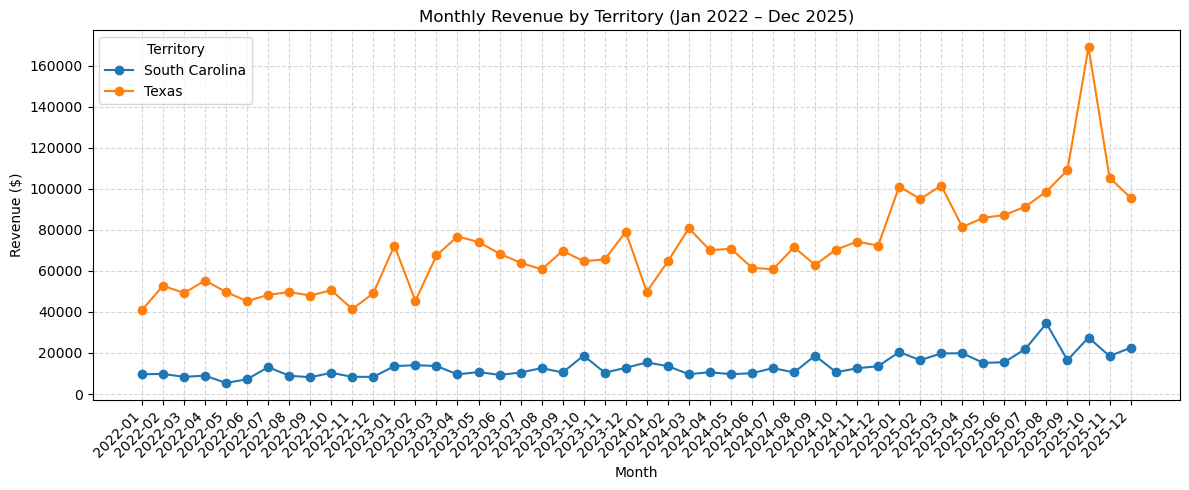

In [22]:
sc_data = monthly_revenue[monthly_revenue['State'] == 'South Carolina']
tx_data = monthly_revenue[monthly_revenue['State'] == 'Texas']

plt.figure(figsize=(12, 5))
plt.plot(sc_data['Year-Month'].astype(str), sc_data['Sale Amount'], marker='o', label='South Carolina')
plt.plot(tx_data['Year-Month'].astype(str), tx_data['Sale Amount'], marker='o', label='Texas')

plt.title('Monthly Revenue by Territory (Jan 2022 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Territory')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

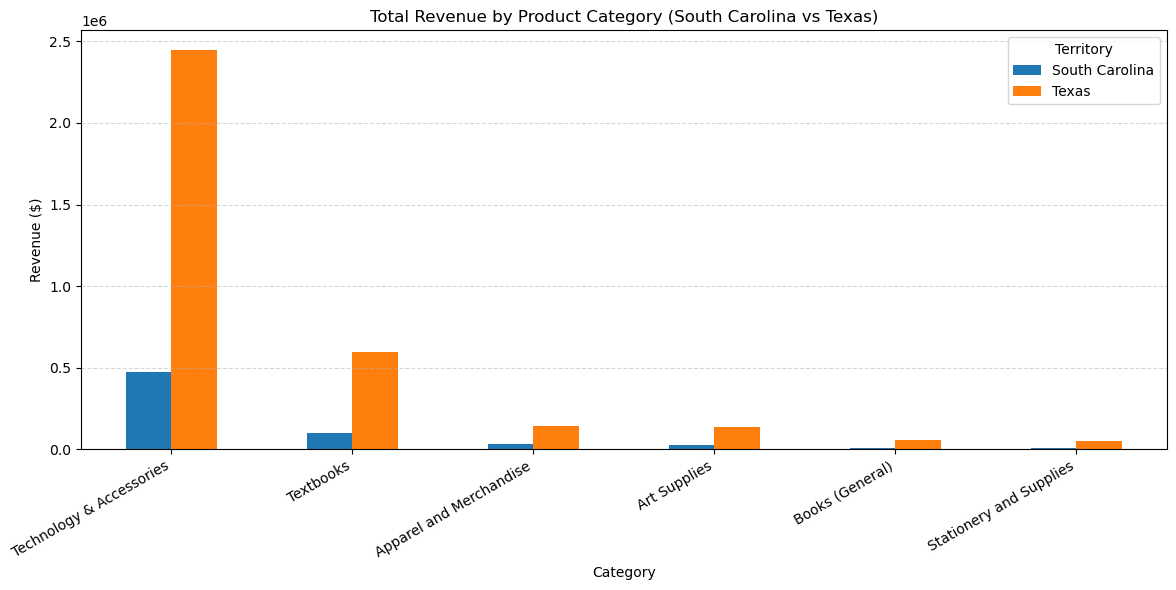

In [23]:
category_pivot = category_totals.pivot_table(
    index='Category',
    columns='State',
    values='Revenue',
    aggfunc='sum'
).fillna(0)

category_pivot = category_pivot.sort_values('Texas', ascending=False)

category_pivot.plot(kind='bar', figsize=(12, 6))

plt.title('Total Revenue by Product Category (South Carolina vs Texas)')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Territory')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()